# Assignment 3: Human Activity Recognition (HAR)

Predict activity label (0–5) from wrist-worn accelerometer data aggregated into 1-second intervals over 5-minute windows.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import model.utils as utils

sns.set_style("whitegrid")
%matplotlib inline

## 1. Load Data

Aggregate each CSV (300 time steps) into per-file statistical features.

In [2]:
DATA_DIR = "data"

X_train, y_train, train_ids, train_users = utils.load_train_data(f"{DATA_DIR}/train/train")
X_test, test_ids, test_users = utils.load_test_data(f"{DATA_DIR}/test/test")

print(f"Train: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]} samples, {X_test.shape[1]} features")

Train: 11020 samples, 82 features
Test:  6849 samples, 82 features


## 2. Exploratory Data Analysis

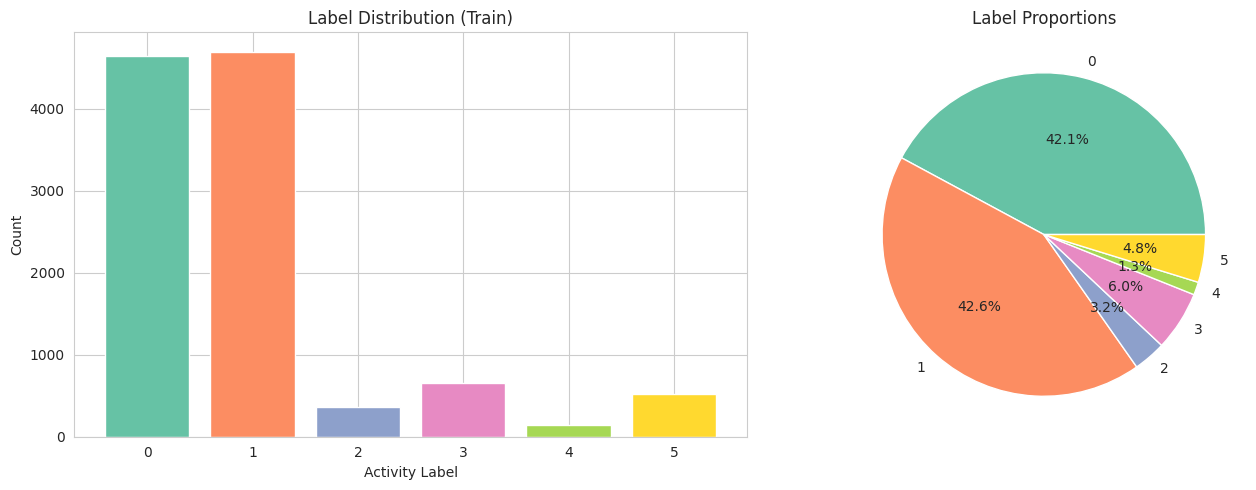


Class counts:
label
0    4643
1    4695
2     358
3     656
4     142
5     526
Name: count, dtype: int64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = y_train.value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values,
           color=sns.color_palette("Set2", 6))
axes[0].set_title("Label Distribution (Train)")
axes[0].set_xlabel("Activity Label")
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=counts.index,
           autopct='%1.1f%%', colors=sns.color_palette("Set2", 6))
axes[1].set_title("Label Proportions")

plt.tight_layout()
plt.show()

print("\nClass counts:")
print(counts)

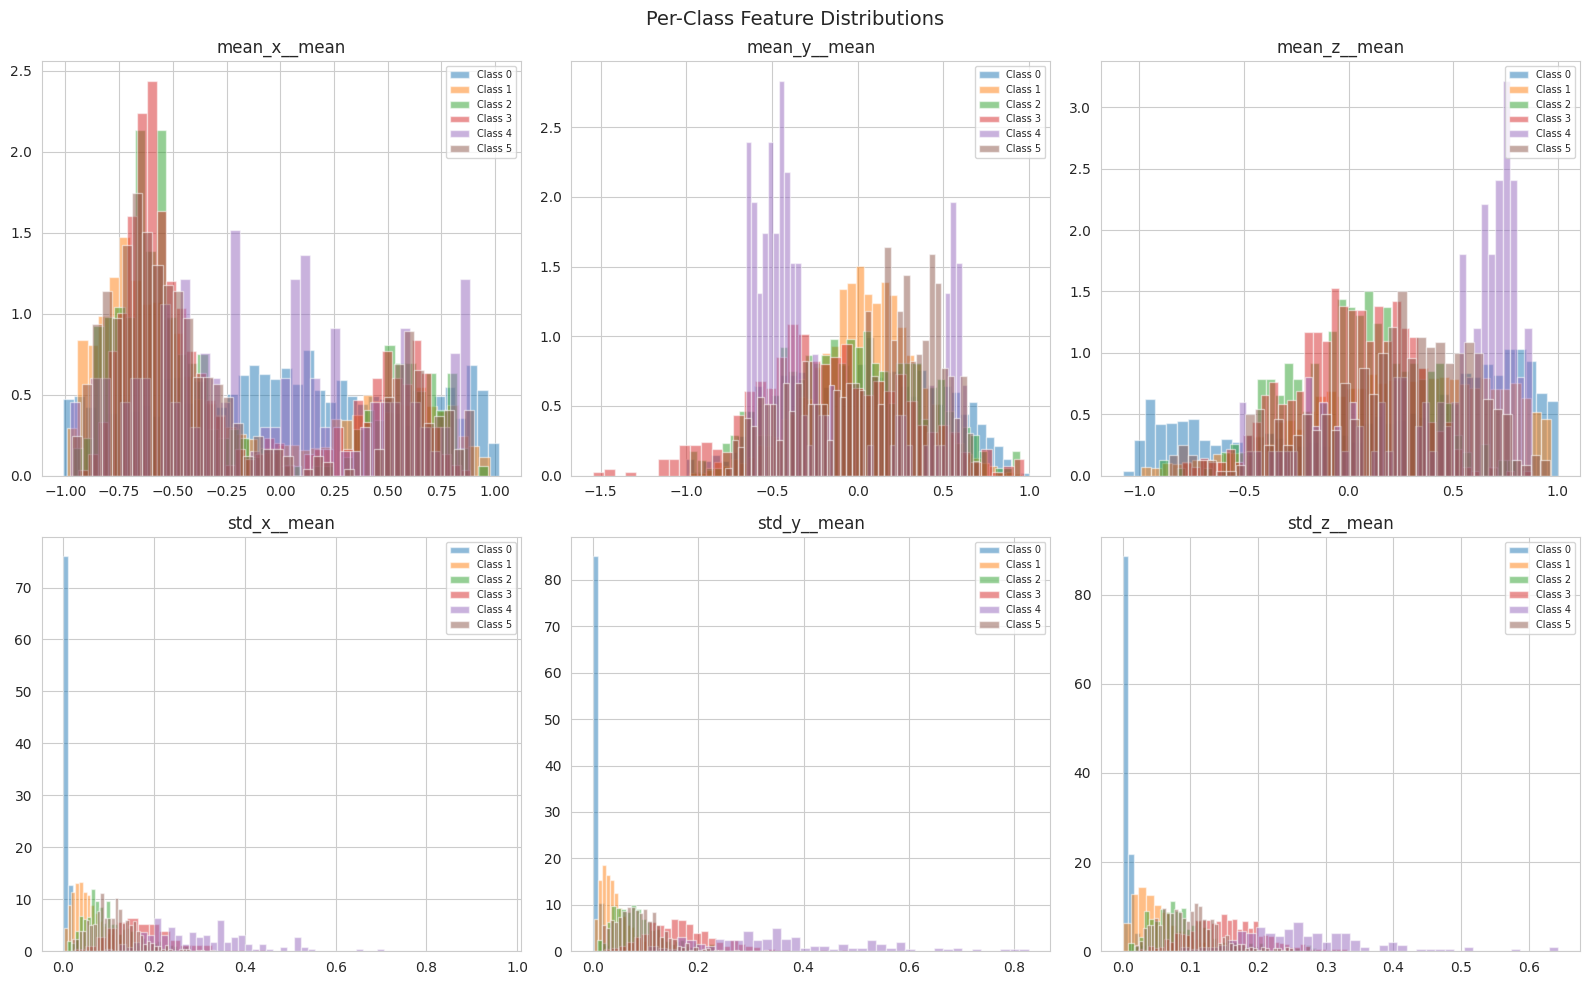

In [4]:
mean_features = ["mean_x__mean", "mean_y__mean", "mean_z__mean",
                "std_x__mean", "std_y__mean", "std_z__mean"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(mean_features):
    for label in range(6):
        mask = y_train == label
        axes[i].hist(X_train.loc[mask, feat], bins=40, alpha=0.5,
                    label=f"Class {label}", density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=7, loc="upper right")

plt.suptitle("Per-Class Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

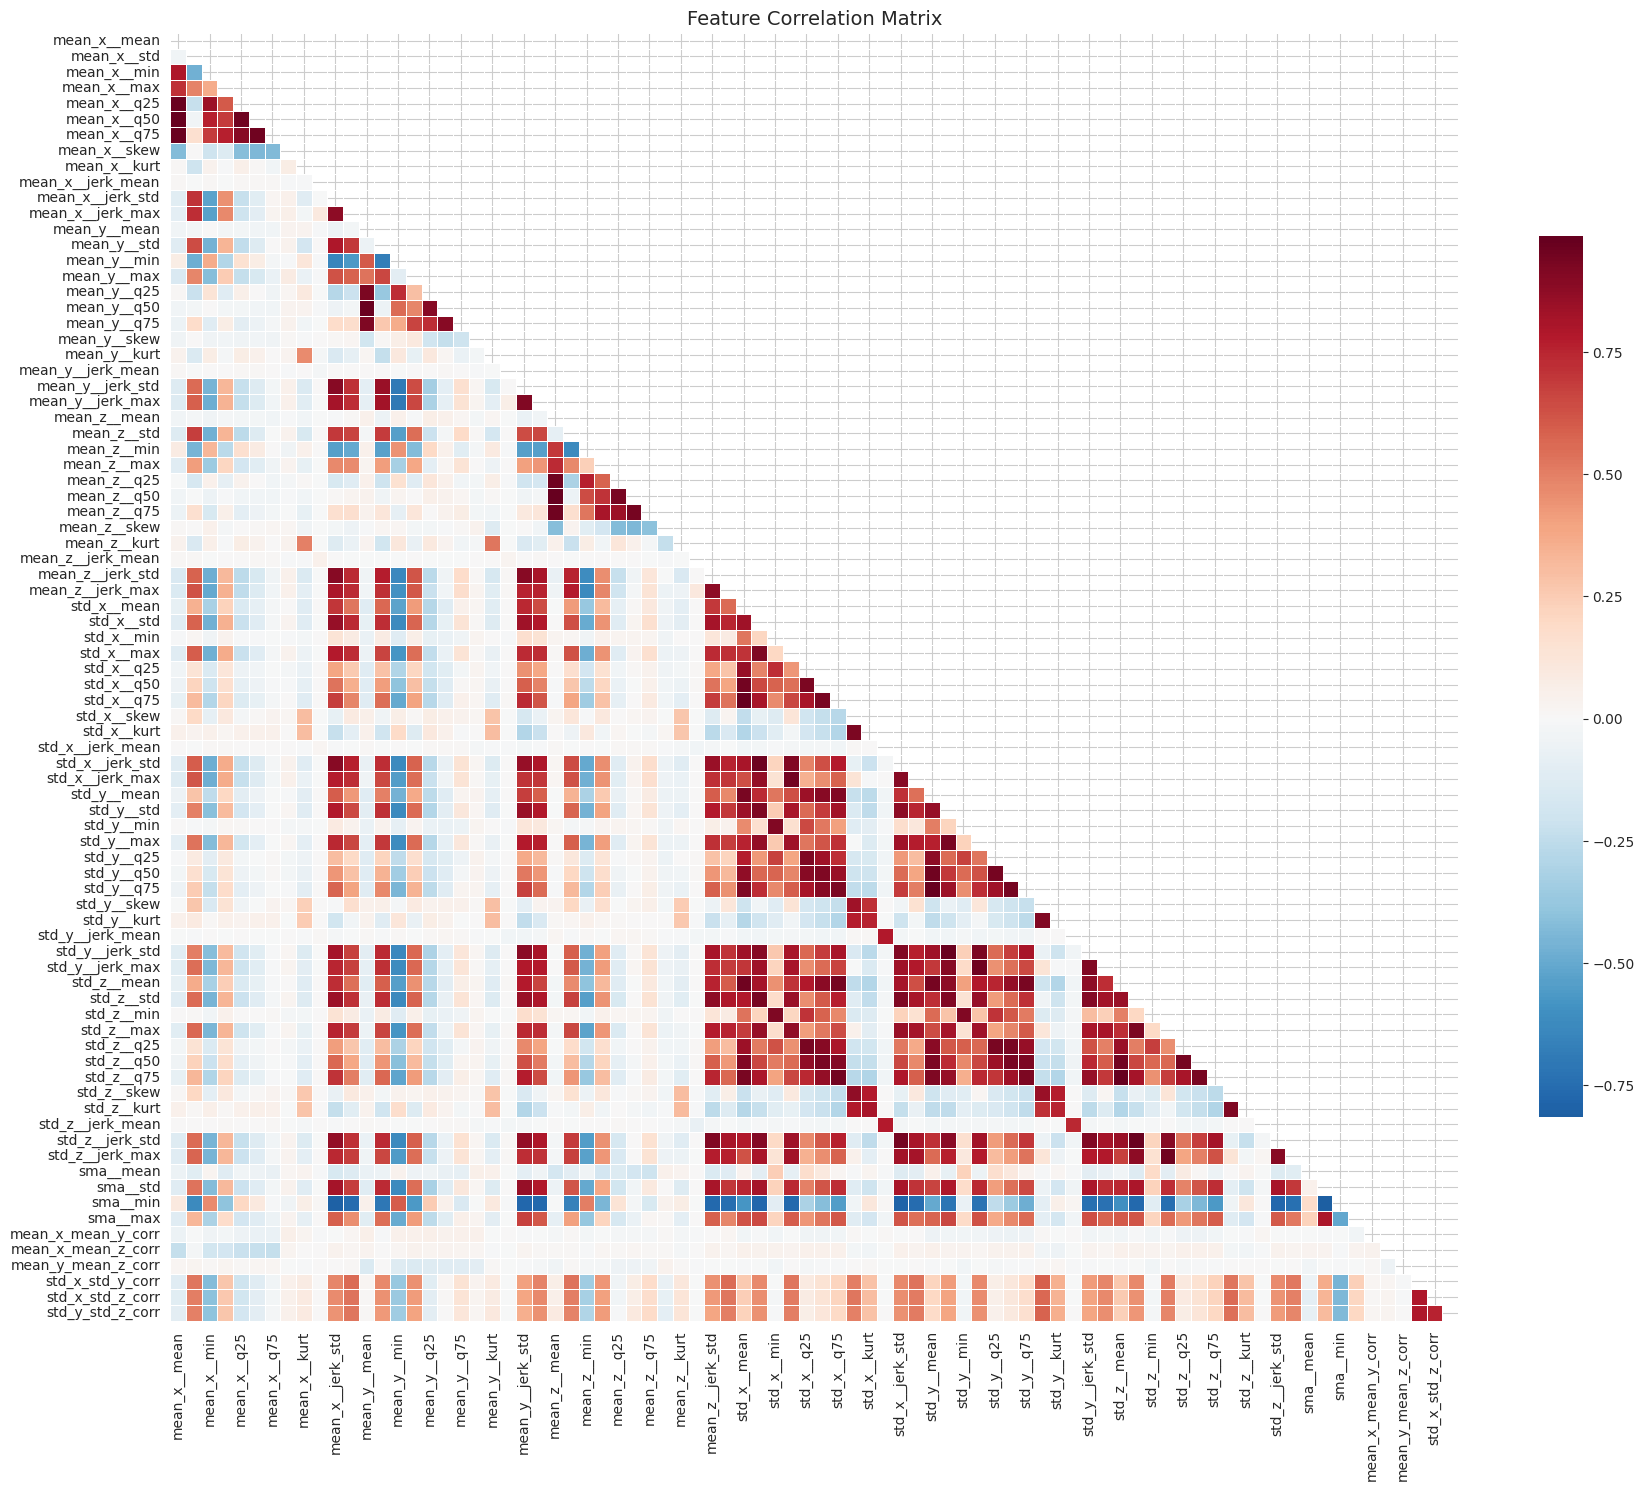

In [5]:
corr = X_train.corr()

fig, ax = plt.subplots(figsize=(18, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.6})
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

**Key observations:**
- Classes 0 and 1 dominate (~84% combined). Classes 2–5 are severely underrepresented.
- mean_z features show clear separation between activities.
- Many features are correlated (especially mean/std derivatives of the same axis).

## 3. Baseline Model

Random Forest with `class_weight='balanced'` and user-based GroupKFold (5 splits).
GroupKFold ensures all samples from the same user stay in the same fold, preventing data leakage.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    model, X_scaled, y_train,
    cv=gkf, groups=train_users,
    scoring="f1_macro", n_jobs=-1
)

for i, s in enumerate(scores, 1):
    print(f"Fold {i}: F1-macro = {s:.4f}")
print(f"\nMean F1-macro: {scores.mean():.4f}  (+/- {scores.std():.4f})")

Fold 1: F1-macro = 0.6072
Fold 2: F1-macro = 0.7132
Fold 3: F1-macro = 0.7005
Fold 4: F1-macro = 0.6657
Fold 5: F1-macro = 0.6195

Mean F1-macro: 0.6612  (+/- 0.0423)


              precision    recall  f1-score   support

           0     0.9442    0.9690    0.9564      4643
           1     0.8497    0.9152    0.8813      4695
           2     0.5000    0.0531    0.0960       358
           3     0.6435    0.7210    0.6801       656
           4     0.9340    0.6972    0.7984       142
           5     0.8276    0.5019    0.6249       526

    accuracy                         0.8758     11020
   macro avg     0.7832    0.6429    0.6728     11020
weighted avg     0.8659    0.8758    0.8621     11020



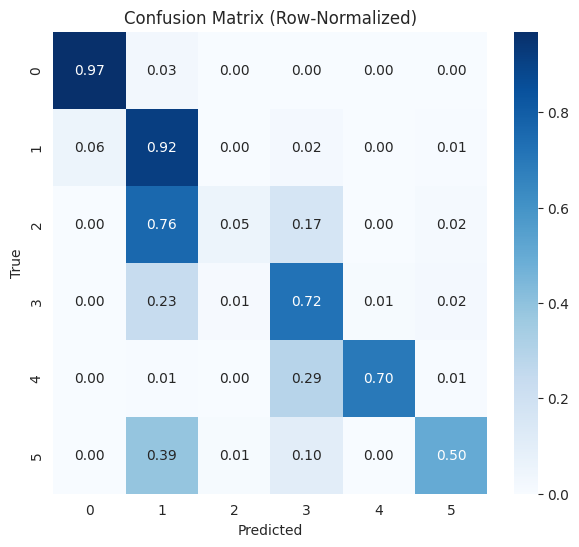

In [7]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(model, X_scaled, y_train,
                              cv=gkf, groups=train_users, n_jobs=-1)

print(classification_report(y_train, y_pred_cv, digits=4))

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_train, y_pred_cv, normalize="true")
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
            xticklabels=range(6), yticklabels=range(6))
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Row-Normalized)")
plt.show()

## 3b. XGBoost + LightGBM Tuning (Optuna)

Optuna searches for best hyperparameters using GroupKFold-5 (user-based splits).

In [8]:
from model.train import tune_xgboost, tune_lightgbm, cv_evaluate
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("=== Tuning XGBoost ===")
xgb_params, xgb_model = tune_xgboost(X_train, y_train, train_users, n_trials=50)

print("Best XGBoost params:", xgb_params)
xgb_scores, xgb_mean, xgb_std = cv_evaluate(xgb_model, X_train, y_train, train_users)
print(f"XGBoost CV F1-macro: {xgb_mean:.4f} (+/- {xgb_std:.4f})")
for i, s in enumerate(xgb_scores, 1):
    print(f"  Fold {i}: {s:.4f}")

/home/tilakoid/miniconda3/envs/datamining/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-16 10:04:26,058] A new study created in memory with name: no-name-f54e1e32-791c-4a5b-9440-0f0512b64049


=== Tuning XGBoost ===


[I 2026-05-16 10:05:06,011] Trial 0 finished with value: 0.6911980299817102 and parameters: {'n_estimators': 437, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08}. Best is trial 0 with value: 0.6911980299817102.


[I 2026-05-16 10:06:01,718] Trial 1 finished with value: 0.6907891467767752 and parameters: {'n_estimators': 880, 'max_depth': 9, 'learning_rate': 0.11114989443094977, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'reg_alpha': 0.31044435499483225, 'reg_lambda': 8.148018307012941e-07}. Best is trial 0 with value: 0.6911980299817102.


[I 2026-05-16 10:06:13,031] Trial 2 finished with value: 0.6728932969843895 and parameters: {'n_estimators': 263, 'max_depth': 4, 'learning_rate': 0.028145092716060652, 'subsample': 0.762378215816119, 'colsample_bytree': 0.7159725093210578, 'reg_alpha': 4.17890272377219e-06, 'reg_lambda': 0.0032112643094417484}. Best is trial 0 with value: 0.6911980299817102.


...

[I 2026-05-16 10:15:40,245] Trial 47 pruned. 


[I 2026-05-16 10:15:52,183] Trial 48 pruned. 


[I 2026-05-16 10:15:56,257] Trial 49 pruned. 


Best XGBoost params: {'n_estimators': 225, 'max_depth': 5, 'learning_rate': 0.03476649150592621, 'subsample': 0.728034992108518, 'colsample_bytree': 0.8925879806965068, 'reg_alpha': 6.267062696005991e-07, 'reg_lambda': 0.00042472707398058225, 'random_state': 42, 'n_jobs': -1}


XGBoost CV F1-macro: 0.6916 (+/- 0.0282)
  Fold 1: 0.6535
  Fold 2: 0.7237
  Fold 3: 0.7234
  Fold 4: 0.6700
  Fold 5: 0.6875


In [9]:
print("\n=== Tuning LightGBM ===")
lgb_params, lgb_model = tune_lightgbm(X_train, y_train, train_users, n_trials=50)

print("Best LightGBM params:", lgb_params)
lgb_scores, lgb_mean, lgb_std = cv_evaluate(lgb_model, X_train, y_train, train_users)
print(f"LightGBM CV F1-macro: {lgb_mean:.4f} (+/- {lgb_std:.4f})")
for i, s in enumerate(lgb_scores, 1):
    print(f"  Fold {i}: {s:.4f}")

[I 2026-05-16 10:16:15,311] A new study created in memory with name: no-name-3b67f8fb-6ac0-45d3-a2ef-425a307608ca



=== Tuning LightGBM ===


/home/tilakoid/miniconda3/envs/datamining/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tilakoid/miniconda3/envs/datamining/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tilakoid/miniconda3/envs/datamining/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/home/tilakoid/miniconda3/envs/datamining/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tilakoid/miniconda3/envs/datamining/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tilakoid/miniconda3/envs/datamining/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM CV F1-macro: 0.7010 (+/- 0.0336)
  Fold 1: 0.6608
  Fold 2: 0.7333
  Fold 3: 0.7476
  Fold 4: 0.6756
  Fold 5: 0.6879


/home/tilakoid/miniconda3/envs/datamining/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 3c. Ensemble Prediction & Submission

Average  from both models, then . Also save individual model predictions for comparison.

In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import model.utils as utils
import os

os.makedirs("output", exist_ok=True)

# Scale full training data for fitting
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train)

xgb_model.fit(X_train_scaled, y_train)
lgb_model.fit(X_train_scaled, y_train)

# Scale test data
X_test_scaled = scaler_full.transform(X_test)

# XGBoost predictions
xgb_preds = xgb_model.predict(X_test_scaled)
utils.generate_submission(test_ids, xgb_preds, "output/submission_xgb.csv")

# LightGBM predictions
lgb_preds = lgb_model.predict(X_test_scaled)
utils.generate_submission(test_ids, lgb_preds, "output/submission_lgb.csv")

# Ensemble: average probabilities
xgb_proba = xgb_model.predict_proba(X_test_scaled)
lgb_proba = lgb_model.predict_proba(X_test_scaled)
ensemble_proba = (xgb_proba + lgb_proba) / 2
ensemble_preds = np.argmax(ensemble_proba, axis=1)
utils.generate_submission(test_ids, ensemble_preds, "output/submission_ensemble.csv")

print("Saved:")
print("  output/submission_xgb.csv")
print("  output/submission_lgb.csv")
print("  output/submission_ensemble.csv")

Saved 6849 rows -> output/submission_xgb.csv


/home/tilakoid/miniconda3/envs/datamining/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved 6849 rows -> output/submission_lgb.csv


/home/tilakoid/miniconda3/envs/datamining/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved 6849 rows -> output/submission_ensemble.csv
Saved:
  output/submission_xgb.csv
  output/submission_lgb.csv
  output/submission_ensemble.csv


## 4. Test Prediction & Submission

In [11]:
model.fit(X_scaled, y_train)

X_test_scaled = scaler.transform(X_test)
test_preds = model.predict(X_test_scaled)

utils.generate_submission(test_ids, test_preds, "output/submission_baseline_rf.csv")

Saved 6849 rows -> output/submission_baseline_rf.csv


## 5. Improvement Directions

Current baseline aggregating 300 time steps into global statistics discards temporal structure.

**Ideas to explore:**

| Direction | Description |
|---|---|
| Temporal models | LSTM / GRU / 1D-CNN over raw 300-step sequences |
| More features | FFT coefficients, rolling window stats, jerk (derivative), signal magnitude area |
| Class imbalance | SMOTE, ADASYN, or custom sampler for minority classes |
| Feature selection | RFE, mutual information to drop redundant 42 features |
| Ensemble | XGBoost / LightGBM with tuned hyperparams + bagging |
| User normalization | Per-user feature normalization to reduce inter-subject variability |
| Window splitting | Treat each CSV as 5 x 1-min windows for more training samples |